In [1]:
# ============================================================
#  PERSONAL LOAN ACCEPTANCE PREDICTION
#  Bank Marketing Dataset - Full ML Pipeline
# ============================================================

# ── 1. IMPORT LIBRARIES ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, mean_absolute_error,
    mean_squared_error, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
# ── 2. LOAD DATASET ──────────────────────────────────────────
# Download from: https://archive.ics.uci.edu/ml/datasets/bank+marketing
# Use the 'bank-full.csv' file (semicolon separated)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"

# If loading from local file:
# df = pd.read_csv("bank-full.csv", sep=";")

# Load directly from URL (bank.csv inside the zip)
import urllib.request, zipfile, io

response = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.read()))
df = pd.read_csv(zip_file.open("bank.csv"), sep=";")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [3]:
# ── 3. DATASET UNDERSTANDING ─────────────────────────────────
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)

print("\n--- Column Names & Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Basic Statistics ---")
df.describe()


  DATASET OVERVIEW

--- Column Names & Data Types ---
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

--- Missing Values ---
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

--- Basic Statistics ---


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


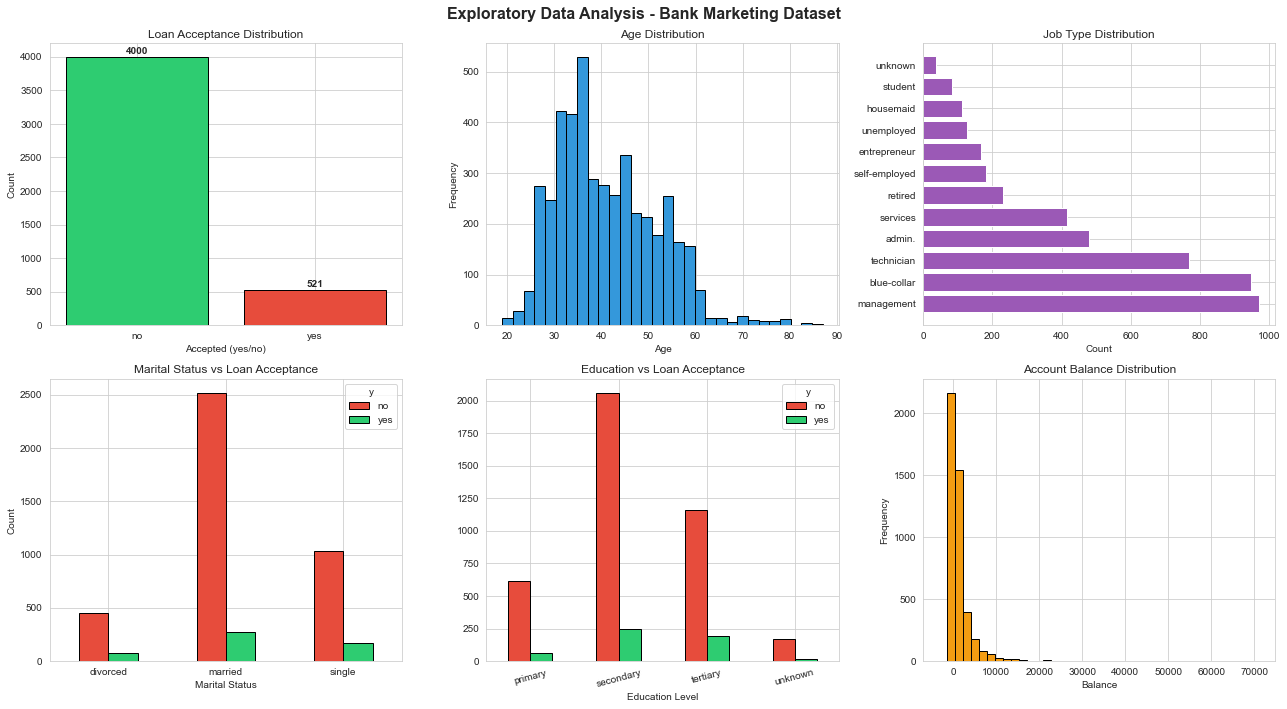

EDA plot saved!


In [4]:
# ── 4. EXPLORATORY DATA ANALYSIS (EDA) ──────────────────────

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Exploratory Data Analysis - Bank Marketing Dataset",
             fontsize=16, fontweight="bold")

# (a) Target Variable Distribution
target_counts = df["y"].value_counts()
axes[0, 0].bar(target_counts.index, target_counts.values,
               color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0, 0].set_title("Loan Acceptance Distribution")
axes[0, 0].set_xlabel("Accepted (yes/no)")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(target_counts.values):
    axes[0, 0].text(i, v + 50, str(v), ha="center", fontweight="bold")

# (b) Age Distribution
axes[0, 1].hist(df["age"], bins=30, color="#3498db", edgecolor="black")
axes[0, 1].set_title("Age Distribution")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Frequency")

# (c) Job Type Distribution
job_counts = df["job"].value_counts()
axes[0, 2].barh(job_counts.index, job_counts.values, color="#9b59b6")
axes[0, 2].set_title("Job Type Distribution")
axes[0, 2].set_xlabel("Count")

# (d) Marital Status vs Loan Acceptance
marital_loan = df.groupby(["marital", "y"]).size().unstack()
marital_loan.plot(kind="bar", ax=axes[1, 0],
                  color=["#e74c3c", "#2ecc71"], edgecolor="black")
axes[1, 0].set_title("Marital Status vs Loan Acceptance")
axes[1, 0].set_xlabel("Marital Status")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis="x", rotation=0)

# (e) Education vs Loan Acceptance
edu_loan = df.groupby(["education", "y"]).size().unstack()
edu_loan.plot(kind="bar", ax=axes[1, 1],
              color=["#e74c3c", "#2ecc71"], edgecolor="black")
axes[1, 1].set_title("Education vs Loan Acceptance")
axes[1, 1].set_xlabel("Education Level")
axes[1, 1].tick_params(axis="x", rotation=15)

# (f) Balance Distribution
axes[1, 2].hist(df["balance"], bins=40, color="#f39c12", edgecolor="black")
axes[1, 2].set_title("Account Balance Distribution")
axes[1, 2].set_xlabel("Balance")
axes[1, 2].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("eda_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA plot saved!")


In [5]:
# ── 5. DATA CLEANING & PREPROCESSING ────────────────────────

# (a) Copy the dataframe
data = df.copy()

# (b) Encode Target Variable
data["y"] = data["y"].map({"yes": 1, "no": 0})

# (c) Encode Categorical Columns with LabelEncoder
categorical_cols = data.select_dtypes(include=["object"]).columns
le = LabelEncoder()

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

print("Categorical columns encoded:", list(categorical_cols))

# (d) Feature & Target Split
X = data.drop("y", axis=1)
y = data["y"]

print("\nFeatures Shape:", X.shape)
print("Target Shape  :", y.shape)
print("\nClass Distribution:\n", y.value_counts())


Categorical columns encoded: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Features Shape: (4521, 16)
Target Shape  : (4521,)

Class Distribution:
 0    4000
1     521
Name: y, dtype: int64


In [6]:
# (e) Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# (f) Feature Scaling (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training Set  : {X_train.shape}")
print(f"Testing Set   : {X_test.shape}")


Training Set  : (3616, 16)
Testing Set   : (905, 16)


In [7]:
# ── 6. MODEL 1 — LOGISTIC REGRESSION ────────────────────────

print("=" * 55)
print("  MODEL 1: LOGISTIC REGRESSION")
print("=" * 55)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

# Evaluation
lr_acc  = accuracy_score(y_test, lr_pred)
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print(f"\nAccuracy : {lr_acc * 100:.2f}%")
print(f"MAE      : {lr_mae:.4f}")
print(f"RMSE     : {lr_rmse:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=["No", "Yes"]))


  MODEL 1: LOGISTIC REGRESSION

Accuracy : 88.29%
MAE      : 0.1171
RMSE     : 0.3422

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.97      0.94       801
         Yes       0.47      0.18      0.26       104

    accuracy                           0.88       905
   macro avg       0.69      0.58      0.60       905
weighted avg       0.85      0.88      0.86       905



In [8]:
# ── 7. MODEL 2 — DECISION TREE ───────────────────────────────

print("=" * 55)
print("  MODEL 2: DECISION TREE CLASSIFIER")
print("=" * 55)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

# Evaluation
dt_acc  = accuracy_score(y_test, dt_pred)
dt_mae  = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

print(f"\nAccuracy : {dt_acc * 100:.2f}%")
print(f"MAE      : {dt_mae:.4f}")
print(f"RMSE     : {dt_rmse:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=["No", "Yes"]))


  MODEL 2: DECISION TREE CLASSIFIER

Accuracy : 89.17%
MAE      : 0.1083
RMSE     : 0.3291

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.97      0.94       801
         Yes       0.55      0.33      0.41       104

    accuracy                           0.89       905
   macro avg       0.73      0.65      0.68       905
weighted avg       0.87      0.89      0.88       905



In [15]:
!pip install --upgrade scikit-learn




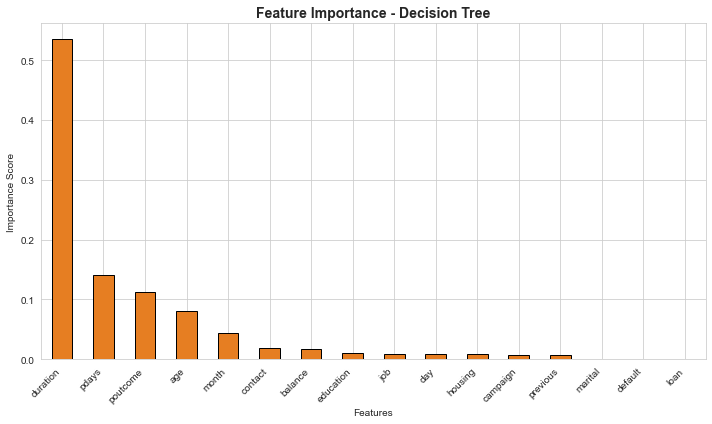


Top 5 Important Features:
duration    0.535112
pdays       0.140810
poutcome    0.111859
age         0.080150
month       0.044723
dtype: float64


In [18]:
# ── 8. FEATURE IMPORTANCE (Decision Tree) ────────────────────

feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind="bar", color="#e67e22", edgecolor="black")
plt.title("Feature Importance - Decision Tree", fontsize=14, fontweight="bold")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 Important Features:")
print(feature_importance.head(5))



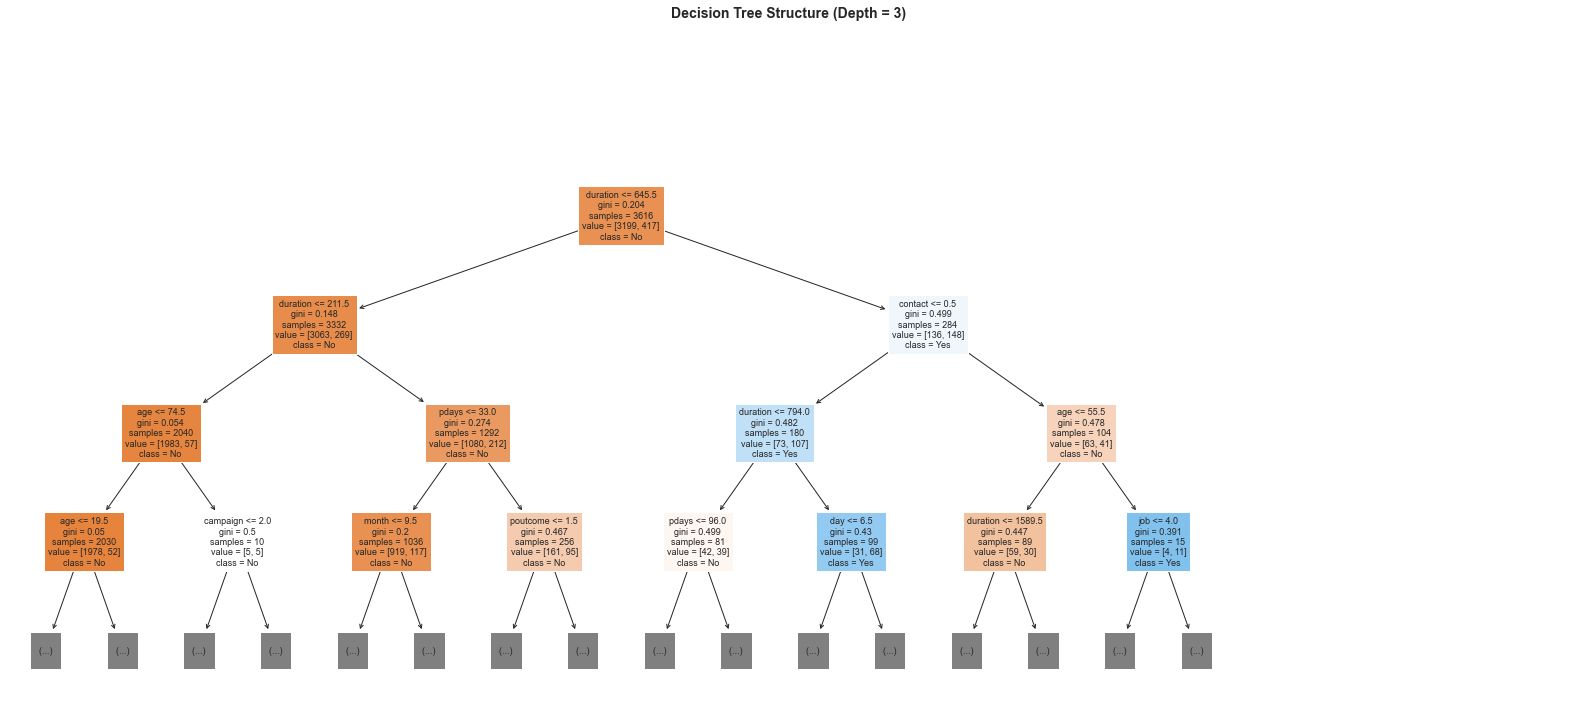

In [19]:
# ── 9. DECISION TREE VISUALIZATION ──────────────────────────

plt.figure(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Structure (Depth = 3)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()


  MODEL COMPARISON SUMMARY
              Model  Accuracy    MAE   RMSE
Logistic Regression     88.29 0.1171 0.3422
      Decision Tree     89.17 0.1083 0.3291


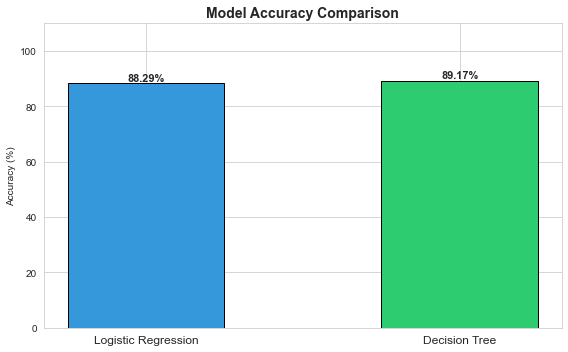

In [20]:
# ── 10. MODEL COMPARISON ─────────────────────────────────────

comparison = pd.DataFrame({
    "Model"   : ["Logistic Regression", "Decision Tree"],
    "Accuracy": [round(lr_acc * 100, 2), round(dt_acc * 100, 2)],
    "MAE"     : [round(lr_mae, 4),       round(dt_mae, 4)],
    "RMSE"    : [round(lr_rmse, 4),      round(dt_rmse, 4)]
})

print("=" * 55)
print("  MODEL COMPARISON SUMMARY")
print("=" * 55)
print(comparison.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
bars = ax.bar(x, comparison["Accuracy"],
              color=["#3498db", "#2ecc71"],
              width=0.5, edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], fontsize=12)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
ax.set_ylim(0, 110)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{bar.get_height():.2f}%",
            ha="center", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [21]:
# ── 11. CONCLUSION ───────────────────────────────────────────

print("""
============================================================
  CONCLUSION
============================================================

TASK    : Personal Loan Acceptance Prediction
DATASET : UCI Bank Marketing Dataset

KEY FINDINGS:
  - The dataset is imbalanced (majority "no" class).
  - Important features: duration, balance, age, campaign.
  - Customers with longer call duration & higher balance
    are more likely to accept a personal loan.

MODEL PERFORMANCE:
  - Logistic Regression Accuracy : {lr:.2f}%
  - Decision Tree Accuracy       : {dt:.2f}%

BEST MODEL: {best}

BUSINESS INSIGHT:
  - Focus marketing campaigns on customers aged 25-40
    with positive account balances.
  - Longer phone call durations correlate strongly with
    loan acceptance — prioritize engaged customers.
============================================================
""".format(
    lr=lr_acc * 100,
    dt=dt_acc * 100,
    best="Logistic Regression" if lr_acc > dt_acc else "Decision Tree"
))



  CONCLUSION

TASK    : Personal Loan Acceptance Prediction
DATASET : UCI Bank Marketing Dataset

KEY FINDINGS:
  - The dataset is imbalanced (majority "no" class).
  - Important features: duration, balance, age, campaign.
  - Customers with longer call duration & higher balance
    are more likely to accept a personal loan.

MODEL PERFORMANCE:
  - Logistic Regression Accuracy : 88.29%
  - Decision Tree Accuracy       : 89.17%

BEST MODEL: Decision Tree

BUSINESS INSIGHT:
  - Focus marketing campaigns on customers aged 25-40
    with positive account balances.
  - Longer phone call durations correlate strongly with
    loan acceptance — prioritize engaged customers.

